# Analyse Experiment Results #

In [47]:
import os
import ast
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

## Analyse Dataset Selection Experiments with Negative Sampling & Smoothing Factor using Cold Start Setting (03/03)

In [48]:
## util methods ##

def parse_cell(x):
    """
    Convert a cell into a Python object.
    Handles cases where the cell is already a list
    or stored as a string representation of a list.
    """
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return None
    if isinstance(x, str):
        x = x.strip()
        try:
            return ast.literal_eval(x)
        except Exception:
            try:
                return json.loads(x)
            except Exception:
                return None
    return x


def avg_fold_metrics(fold_value):
    """
    fold_value should be a list of 10 sublists, each sublist like:
    [auc, aupr, precision, sensitivity, specificity]

    Returns:
    [avg_auc, avg_aupr, avg_precision, avg_sensitivity, avg_specificity]
    """
    fold_value = parse_cell(fold_value)

    if not fold_value:
        return [np.nan] * 5

    arr = np.array(fold_value, dtype=float)   # shape should be (10, 5)
    return [round(x, 5) for x in arr.mean(axis=0).tolist()]

In [64]:
EXP_0303_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0103_full_.csv'
PREPROCESSED_EXP_0303_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0103_full_preprocessed_.csv'

In [50]:
exp_0303_df = pd.read_csv(EXP_0303_PATH)
exp_0303_df

,exp,val_res,fold1,fold2,fold3,fold4,fold5
0,dataset_neg_fct_1_smoo_fct_1.0,"{ ""fold1"": [0.9750, 0.9726, 0.9307, 0.8851, 0....","[[0.6016, 0.6433, 0.7653, 0.2089, 0.9358], [0....","[[0.7667, 0.7215, 0.7173, 0.2804, 0.8850], [0....","[[0.8376, 0.8186, 0.8265, 0.4757, 0.8988], [0....","[[0.944073054132294, 0.9277799813652652, 0.932...","[[0.8835996251830995, 0.8697932733297292, 0.88..."
1,dataset_neg_fct_1_smoo_fct_0.9,"{""fold1"":[0.9768,0.9736,0.9365,0.9007,0.9423],...","[[0.6007, 0.6280, 0.7372, 0.1707, 0.9391], [0....","[[0.7727, 0.7522, 0.7628, 0.3881, 0.8744], [0....","[[0.7989024049217002, 0.8221505163679286, 0.86...","[[0.9540537315237168, 0.9354342148595752, 0.94...","[[0.8650944897543099, 0.8850325103562866, 0.92..."
2,dataset_neg_fct_2_smoo_fct_0.9,"{""fold1"":[0.9748,0.9548,0.9031,0.8257,0.9559],...","[[0.7378, 0.6769, 0.7033, 0.1481, 0.9375], [0....","[[0.8062, 0.7580, 0.7703, 0.2646, 0.9179], [0....","[[0.8337371022234397, 0.8441065438977506, 0.88...","[[0.964015225094538, 0.9470911197421118, 0.952...","[[0.9447434370181007, 0.9416004664207301, 0.94..."
3,dataset_neg_fct_1_smoo_fct_0.75,"{""fold1"":[0.9795,0.9785,0.9346,0.9043,0.9409],...","[[0.5721, 0.6242, 0.7746, 0.1869, 0.9456], [0....","[[0.7214, 0.7096, 0.7752, 0.2210, 0.9333], [0....","[[0.7612170707209058, 0.7976506121740121, 0.85...","[[0.9507016000110172, 0.9237788358120596, 0.94...","[[0.8920787644261543, 0.8965544069561848, 0.92..."
4,dataset_neg_fct_2_smoo_fct_0.75,"{""fold1"":[0.9746,0.9552,0.9066,0.8554,0.9555],...","[[0.6981, 0.6849, 0.8629, 0.1152, 0.9817], [0....","[[0.7269495243093402, 0.7162602663093225, 0.84...","[[0.8528148255946675, 0.8588808149739873, 0.89...","[[0.951992006669968, 0.9369499528437344, 0.956...","[[0.9029732660777994, 0.9133381123725406, 0.95..."
5,dataset_neg_fct_2_smoo_fct_1.0,"{""fold1"":[0.9803,0.9660,0.9256,0.8655,0.9652],...","[[0.7154, 0.6863, 0.7823, 0.1858, 0.9482], [0....","[[0.8416230448687757, 0.8055108644508907, 0.80...","[[0.8791775099301465, 0.8688276699858073, 0.87...","[[0.9432499181874354, 0.9309212734668767, 0.95...","[[0.9263550886783636, 0.9262720388617698, 0.93..."
6,dataset_neg_fct_3_smoo_fct_0.75,"{""fold1"":[0.9779,0.9463,0.9118,0.8250,0.9728],...","[[0.7762, 0.7320, 0.7642, 0.1449, 0.9553], [0....","[[0.7729, 0.7589, 0.8474, 0.2423, 0.9546], [0....","[[0.8378482685020316, 0.8436183972741491, 0.92...","[[0.9670498590176737, 0.9564984877247174, 0.97...","[[0.9446794252875317, 0.9409524041597631, 0.96..."
7,dataset_neg_fct_4_smoo_fct_0.75,"{""fold1"":[0.9758,0.9310,0.9006,0.7814,0.9774],...","[[0.6797, 0.6744, 0.8391, 0.1179, 0.9774], [0....","[[0.8224, 0.7878, 0.8317, 0.1606, 0.9662], [0....","[[0.8732657912158153, 0.8741262248401045, 0.96...","[[0.9761734804685932, 0.9585030095275707, 0.97...","[[0.9422825698447296, 0.9415528789339255, 0.96..."
8,dataset_neg_fct_3_smoo_fct_0.9,"{""fold1"":[0.9780,0.9503,0.9144,0.8191,0.9734],...","[[0.7425, 0.6980, 0.7193, 0.1766, 0.9310], [0....","[[0.8435392641036339, 0.8130851039175486, 0.87...","[[0.8895941765968132, 0.8809845099234864, 0.92...","[[0.9630167554597128, 0.9436685337599419, 0.95...","[[0.9160307947775783, 0.9215547751384556, 0.96..."
9,dataset_neg_fct_3_smoo_fct_1.0,"{""fold1"":[0.9772,0.9446,0.9031,0.8188,0.9698],...","[[0.7773, 0.7073, 0.7412, 0.2052, 0.9283], [0....","[[0.8499, 0.7829, 0.7922, 0.1878, 0.9488], [0....","[[0.8869432840250193, 0.8766604786185054, 0.92...","[[0.9691313571390258, 0.9544419162255844, 0.96...","[[0.9427451423028056, 0.9394663729574865, 0.96..."


In [51]:
preprocessed_exp_0303_df = exp_0303_df.iloc[:, :].copy() # exclude experiments that still running
preprocessed_exp_0303_df['exp']

0      dataset_neg_fct_1_smoo_fct_1.0
1      dataset_neg_fct_1_smoo_fct_0.9
2      dataset_neg_fct_2_smoo_fct_0.9
3     dataset_neg_fct_1_smoo_fct_0.75
4     dataset_neg_fct_2_smoo_fct_0.75
5      dataset_neg_fct_2_smoo_fct_1.0
6     dataset_neg_fct_3_smoo_fct_0.75
7     dataset_neg_fct_4_smoo_fct_0.75
8      dataset_neg_fct_3_smoo_fct_0.9
9      dataset_neg_fct_3_smoo_fct_1.0
10     dataset_neg_fct_4_smoo_fct_0.9
11    dataset_neg_fct_5_smoo_fct_0.75
12     dataset_neg_fct_5_smoo_fct_1.0
13     dataset_neg_fct_4_smoo_fct_1.0
14     dataset_neg_fct_5_smoo_fct_0.9
Name: exp, dtype: object

In [52]:
preprocessed_exp_0303_df.shape

(15, 7)

In [53]:
# add fold1_avg ... fold5_avg
for i in range(1, 6):
    preprocessed_exp_0303_df[f"fold{i}_avg"] = preprocessed_exp_0303_df[f"fold{i}"].apply(avg_fold_metrics)
preprocessed_exp_0303_df.shape

(15, 12)

In [54]:
# add fold_statistics column; average over the 5 fold averages [auc, aupr, precision, sensitivity, specificity]
def compute_folds_statistics(row):
    '''
    creates folds statistic column which has the mean of each metric
    across all folds (and across its experiments) for auc, aupr,
    precision, sensitivity and specificity;
    [mean_auc_5_folds_experiments, mean_aupr_5_folds_experiments ...]
    # list order -> [auc, aupr, precision, sensitivity, specificity]
    '''
    fold_avgs = []
    for i in range(1, 6):
        val = row[f"fold{i}_avg"]
        val = parse_cell(val)
        if val is not None:
            fold_avgs.append(val)

    if not fold_avgs:
        return [np.nan] * 5

    arr = np.array(fold_avgs, dtype=float)   # shape (5, 5)
    return [round(x, 5) for x in arr.mean(axis=0).tolist()]

In [55]:
preprocessed_exp_0303_df["folds_statistics"] = preprocessed_exp_0303_df.apply(compute_folds_statistics, axis=1)
preprocessed_exp_0303_df.shape

(15, 13)

In [56]:
# add AUC_statistics = [average_auc, variance_auc, std_auc]
# based on the 5 fold average AUCs: fold1_avg[0] ... fold5_avg[0]

def compute_auc_statistics(row):
    aucs = []
    for i in range(1, 6):
        fold_avg = parse_cell(row[f"fold{i}_avg"])
        if fold_avg is not None and len(fold_avg) > 0:
            aucs.append(float(fold_avg[0]))

    if not aucs:
        return [np.nan, np.nan, np.nan]

    aucs = np.array(aucs, dtype=float)
    return [
        float(np.mean(aucs)),
        float(np.var(aucs)),   # population variance
        float(np.std(aucs))    # population std
    ]

In [57]:
preprocessed_exp_0303_df["AUC_statistics"] = preprocessed_exp_0303_df.apply(compute_auc_statistics, axis=1)
preprocessed_exp_0303_df.shape

(15, 14)

In [58]:
# round all columns (5 digits) ...
for col in [f"fold{i}_avg" for i in range(1, 6)] + ["folds_statistics", "AUC_statistics"]:
    preprocessed_exp_0303_df[col] = preprocessed_exp_0303_df[col].apply(
        lambda x: [round(v, 5) if pd.notna(v) else v for v in x] if isinstance(x, list) else x
    )
preprocessed_exp_0303_df.shape

(15, 14)

In [59]:
preprocessed_exp_0303_df.head(1)

,exp,val_res,fold1,fold2,fold3,fold4,fold5,fold1_avg,fold2_avg,fold3_avg,fold4_avg,fold5_avg,folds_statistics,AUC_statistics
0,dataset_neg_fct_1_smoo_fct_1.0,"{ ""fold1"": [0.9750, 0.9726, 0.9307, 0.8851, 0....","[[0.6016, 0.6433, 0.7653, 0.2089, 0.9358], [0....","[[0.7667, 0.7215, 0.7173, 0.2804, 0.8850], [0....","[[0.8376, 0.8186, 0.8265, 0.4757, 0.8988], [0....","[[0.944073054132294, 0.9277799813652652, 0.932...","[[0.8835996251830995, 0.8697932733297292, 0.88...","[0.62391, 0.64394, 0.72782, 0.21657, 0.91778]","[0.77974, 0.74379, 0.75908, 0.30558, 0.89884]","[0.84203, 0.83225, 0.82731, 0.4766, 0.89881]","[0.93869, 0.91978, 0.92114, 0.67452, 0.94132]","[0.88259, 0.88056, 0.89379, 0.64609, 0.92214]","[0.81339, 0.80406, 0.82583, 0.46387, 0.91578]","[0.81339, 0.01167, 0.10802]"


In [60]:
preprocessed_exp_0303_df['exp']

0      dataset_neg_fct_1_smoo_fct_1.0
1      dataset_neg_fct_1_smoo_fct_0.9
2      dataset_neg_fct_2_smoo_fct_0.9
3     dataset_neg_fct_1_smoo_fct_0.75
4     dataset_neg_fct_2_smoo_fct_0.75
5      dataset_neg_fct_2_smoo_fct_1.0
6     dataset_neg_fct_3_smoo_fct_0.75
7     dataset_neg_fct_4_smoo_fct_0.75
8      dataset_neg_fct_3_smoo_fct_0.9
9      dataset_neg_fct_3_smoo_fct_1.0
10     dataset_neg_fct_4_smoo_fct_0.9
11    dataset_neg_fct_5_smoo_fct_0.75
12     dataset_neg_fct_5_smoo_fct_1.0
13     dataset_neg_fct_4_smoo_fct_1.0
14     dataset_neg_fct_5_smoo_fct_0.9
Name: exp, dtype: object

In [ ]:
def parse_if_string(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return x
    return x


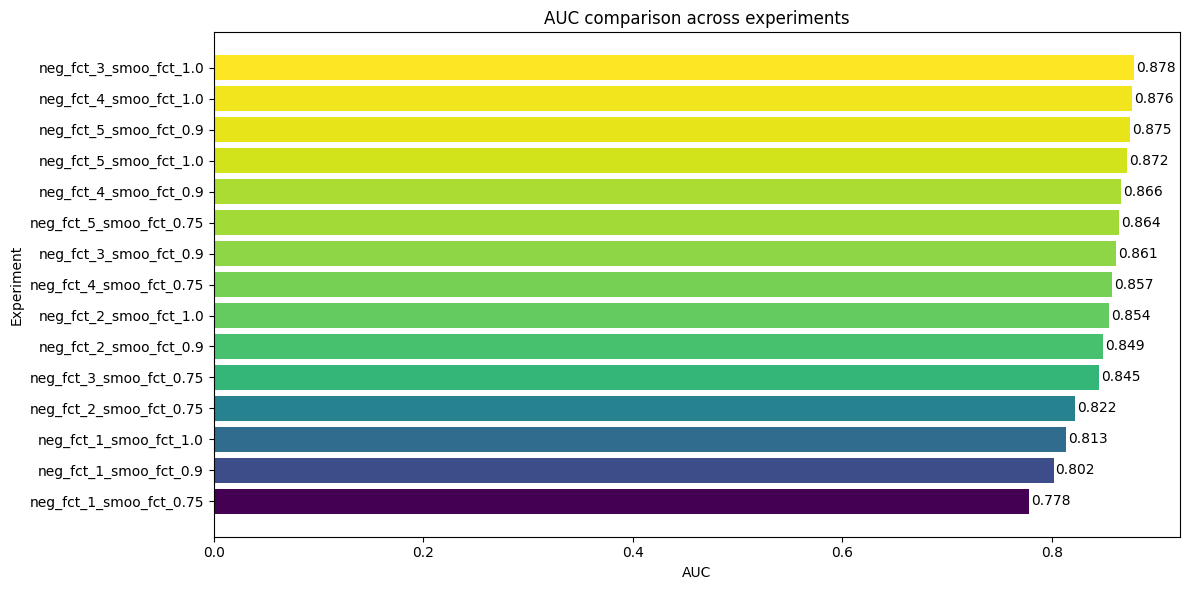

In [44]:

df = preprocessed_exp_0303_df.copy()
df["folds_statistics"] = df["folds_statistics"].apply(parse_if_string)
df = df[df["folds_statistics"].apply(lambda x: isinstance(x, (list, tuple)) and len(x) == 5)].copy()
metric_names = ["AUC", "AUPR", "Precision", "Sensitivity", "Specificity"]

for i, metric in enumerate(metric_names):
    df[metric] = df["folds_statistics"].apply(lambda x: x[i])


df["exp_clean"] = df["exp"].str.replace("dataset_", "", regex=False) # remove "dataset_" from experiment names
df = df.sort_values("AUC", ascending=True).reset_index(drop=True) # sort by AUC

# create colors according to AUC values
norm = mcolors.Normalize(vmin=df["AUC"].min(), vmax=df["AUC"].max())
colors = cm.viridis(norm(df["AUC"]))

# plotting pipeline ..
plt.figure(figsize=(12,6))
bars = plt.barh(df["exp_clean"], df["AUC"], color=colors)

plt.title("AUC comparison across experiments")
plt.xlabel("AUC")
plt.ylabel("Experiment")

for bar, value in zip(bars, df["AUC"]):
    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [63]:
preprocessed_exp_0303_df

,exp,val_res,fold1,fold2,fold3,fold4,fold5,fold1_avg,fold2_avg,fold3_avg,fold4_avg,fold5_avg,folds_statistics,AUC_statistics
0,dataset_neg_fct_1_smoo_fct_1.0,"{ ""fold1"": [0.9750, 0.9726, 0.9307, 0.8851, 0....","[[0.6016, 0.6433, 0.7653, 0.2089, 0.9358], [0....","[[0.7667, 0.7215, 0.7173, 0.2804, 0.8850], [0....","[[0.8376, 0.8186, 0.8265, 0.4757, 0.8988], [0....","[[0.944073054132294, 0.9277799813652652, 0.932...","[[0.8835996251830995, 0.8697932733297292, 0.88...","[0.62391, 0.64394, 0.72782, 0.21657, 0.91778]","[0.77974, 0.74379, 0.75908, 0.30558, 0.89884]","[0.84203, 0.83225, 0.82731, 0.4766, 0.89881]","[0.93869, 0.91978, 0.92114, 0.67452, 0.94132]","[0.88259, 0.88056, 0.89379, 0.64609, 0.92214]","[0.81339, 0.80406, 0.82583, 0.46387, 0.91578]","[0.81339, 0.01167, 0.10802]"
1,dataset_neg_fct_1_smoo_fct_0.9,"{""fold1"":[0.9768,0.9736,0.9365,0.9007,0.9423],...","[[0.6007, 0.6280, 0.7372, 0.1707, 0.9391], [0....","[[0.7727, 0.7522, 0.7628, 0.3881, 0.8744], [0....","[[0.7989024049217002, 0.8221505163679286, 0.86...","[[0.9540537315237168, 0.9354342148595752, 0.94...","[[0.8650944897543099, 0.8850325103562866, 0.92...","[0.58777, 0.61799, 0.72594, 0.18455, 0.92977]","[0.7804, 0.74897, 0.76422, 0.35757, 0.88523]","[0.8122, 0.8291, 0.8634, 0.45889, 0.92611]","[0.94605, 0.92974, 0.93792, 0.69027, 0.95365]","[0.88175, 0.89072, 0.91878, 0.5762, 0.94832]","[0.80163, 0.8033, 0.84205, 0.4535, 0.92862]","[0.80163, 0.01471, 0.12131]"
2,dataset_neg_fct_2_smoo_fct_0.9,"{""fold1"":[0.9748,0.9548,0.9031,0.8257,0.9559],...","[[0.7378, 0.6769, 0.7033, 0.1481, 0.9375], [0....","[[0.8062, 0.7580, 0.7703, 0.2646, 0.9179], [0....","[[0.8337371022234397, 0.8441065438977506, 0.88...","[[0.964015225094538, 0.9470911197421118, 0.952...","[[0.9447434370181007, 0.9416004664207301, 0.94...","[0.69817, 0.66844, 0.7253, 0.16068, 0.93898]","[0.79672, 0.7599, 0.79056, 0.2547, 0.93005]","[0.86516, 0.864, 0.88715, 0.39673, 0.94898]","[0.9544, 0.93824, 0.95435, 0.60743, 0.97052]","[0.93215, 0.93117, 0.9467, 0.55731, 0.96808]","[0.84932, 0.83235, 0.86081, 0.39537, 0.95132]","[0.84932, 0.00875, 0.09356]"
3,dataset_neg_fct_1_smoo_fct_0.75,"{""fold1"":[0.9795,0.9785,0.9346,0.9043,0.9409],...","[[0.5721, 0.6242, 0.7746, 0.1869, 0.9456], [0....","[[0.7214, 0.7096, 0.7752, 0.2210, 0.9333], [0....","[[0.7612170707209058, 0.7976506121740121, 0.85...","[[0.9507016000110172, 0.9237788358120596, 0.94...","[[0.8920787644261543, 0.8965544069561848, 0.92...","[0.60845, 0.64655, 0.7939, 0.19181, 0.92999]","[0.69339, 0.70316, 0.78021, 0.24438, 0.92878]","[0.76096, 0.80106, 0.87733, 0.41359, 0.9409]","[0.93275, 0.91672, 0.94432, 0.64939, 0.9612]","[0.89689, 0.90496, 0.93041, 0.57401, 0.95646]","[0.77849, 0.79449, 0.86523, 0.41464, 0.94347]","[0.77849, 0.01486, 0.12188]"
4,dataset_neg_fct_2_smoo_fct_0.75,"{""fold1"":[0.9746,0.9552,0.9066,0.8554,0.9555],...","[[0.6981, 0.6849, 0.8629, 0.1152, 0.9817], [0....","[[0.7269495243093402, 0.7162602663093225, 0.84...","[[0.8528148255946675, 0.8588808149739873, 0.89...","[[0.951992006669968, 0.9369499528437344, 0.956...","[[0.9029732660777994, 0.9133381123725406, 0.95...","[0.66005, 0.64468, 0.82095, 0.13533, 0.96782]","[0.73975, 0.73212, 0.82801, 0.21718, 0.95333]","[0.83858, 0.85292, 0.90655, 0.40361, 0.95757]","[0.96277, 0.9482, 0.96063, 0.61292, 0.97457]","[0.9106, 0.91632, 0.95793, 0.51436, 0.97709]","[0.82235, 0.81885, 0.89481, 0.37668, 0.96608]","[0.82235, 0.01219, 0.11039]"
5,dataset_neg_fct_2_smoo_fct_1.0,"{""fold1"":[0.9803,0.9660,0.9256,0.8655,0.9652],...","[[0.7154, 0.6863, 0.7823, 0.1858, 0.9482], [0....","[[0.8416230448687757, 0.8055108644508907, 0.80...","[[0.8791775099301465, 0.8688276699858073, 0.87...","[[0.9432499181874354, 0.9309212734668767, 0.95...","[[0.9263550886783636, 0.9262720388617698, 0.93...","[0.71291, 0.69305, 0.77182, 0.19274, 0.94242]","[0.82978, 0.7932, 0.8068, 0.30474, 0.92464]","[0.85152, 0.85157, 0.87953, 0.40654, 0.94337]","[0.95545, 0.94053, 0.95346, 0.65546, 0.96761]","[0.922, 0.92329, 0.93156, 0.60

In [65]:
preprocessed_exp_0303_df.to_csv(PREPROCESSED_EXP_0303_PATH, index=False)